# Diamond Price Prediction — Review 1 Regression

The notebook builds the complete Review 1 regression track: audit and EDA, cleaning and feature engineering, leakage-safe preprocessing, all ten required regressors, tuning, comparison, and validation of the two leading models.

Every model uses the same 80/20 split and the same test rows.

## 1. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

sns.set_theme(style="whitegrid", palette="colorblind")
RANDOM_STATE = 42

## 2. Load and audit the data

The path helper allows the notebook to run from either the project root or the `models/` directory.

In [2]:
def find_data_file(filename):
    candidates = [
        Path.cwd() / "data" / filename,
        Path.cwd().parent / "data" / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find {filename} from {Path.cwd()}")


data_path = find_data_file("diamond.csv")
diamonds = pd.read_csv(data_path)
print(f"Original shape: {diamonds.shape}")
diamonds.head()

Original shape: (53940, 10)
Out[0]: 
   Carat(Weight of Daimond) Cut(Quality) Color  ... X(length)  Y(width)  Z(Depth)
0                      0.23        Ideal     E  ...      3.95      3.98      2.43
1                      0.21      Premium     E  ...      3.89      3.84      2.31
2                      0.23         Good     E  ...      4.05      4.07      2.31
3                      0.29      Premium     I  ...      4.20      4.23      2.63
4                      0.31         Good     J  ...      4.34      4.35      2.75

[5 rows x 10 columns]


### Use concise column names

The source headers contain spaces and descriptions. Short names make later feature lists and plots easier to read.

In [3]:
diamonds = diamonds.rename(
    columns={
        "Carat(Weight of Daimond)": "carat",
        "Cut(Quality)": "cut",
        "Color": "color",
        "Clarity": "clarity",
        "Depth": "depth",
        "Table": "table",
        "Price(in US dollars)": "price",
        "X(length)": "x",
        "Y(width)": "y",
        "Z(Depth)": "z",
    }
)
diamonds.head()

Out[0]: 
   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75


### Data-quality audit

The audit reports data types, missing values, unique values, duplicate rows, and descriptive statistics before cleaning.

In [4]:
diamonds.info()

quality_report = pd.DataFrame(
    {
        "data_type": diamonds.dtypes.astype(str),
        "missing_values": diamonds.isna().sum(),
        "unique_values": diamonds.nunique(),
    }
)
print(f"Duplicate rows: {diamonds.duplicated().sum()}")
quality_report

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  str    
 2   color    53940 non-null  str    
 3   clarity  53940 non-null  str    
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.1 MB
Duplicate rows: 146
Out[0]: 
        data_type  missing_values  unique_values
carat     float64               0            273
cut           str               0              5
color         str               0              7
clarity       str               0              8
depth     float64               0            184
table     float64               0            127
price       int6

In [5]:
diamonds.describe(include="all").T

Out[0]: 
           count unique    top   freq  ...    25%     50%      75%      max
carat    53940.0    NaN    NaN    NaN  ...    0.4     0.7     1.04     5.01
cut        53940      5  Ideal  21551  ...    NaN     NaN      NaN      NaN
color      53940      7      G  11292  ...    NaN     NaN      NaN      NaN
clarity    53940      8    SI1  13065  ...    NaN     NaN      NaN      NaN
depth    53940.0    NaN    NaN    NaN  ...   61.0    61.8     62.5     79.0
table    53940.0    NaN    NaN    NaN  ...   56.0    57.0     59.0     95.0
price    53940.0    NaN    NaN    NaN  ...  950.0  2401.0  5324.25  18823.0
x        53940.0    NaN    NaN    NaN  ...   4.71     5.7     6.54    10.74
y        53940.0    NaN    NaN    NaN  ...   4.72    5.71     6.54     58.9
z        53940.0    NaN    NaN    NaN  ...   2.91    3.53     4.04     31.8

[10 rows x 11 columns]


### Clean duplicates and invalid measurements

Exact duplicates are removed before splitting so repeated records cannot land in both sets. A physical diamond cannot have zero or negative length, width, or depth, so those rows are also removed. Missing-value imputers remain in the pipeline for robustness.

In [6]:
dimension_columns = ["x", "y", "z"]
duplicate_count = diamonds.duplicated().sum()
invalid_dimensions = (diamonds[dimension_columns] <= 0).any(axis=1)

diamonds_clean = (
    diamonds.loc[~invalid_dimensions]
    .drop_duplicates()
    .reset_index(drop=True)
)

print(f"Duplicate rows removed: {duplicate_count:,}")
print(f"Rows with invalid dimensions removed: {invalid_dimensions.sum():,}")
print(f"Cleaned shape: {diamonds_clean.shape}")

Duplicate rows removed: 146
Rows with invalid dimensions removed: 20
Cleaned shape: (53775, 10)


## 3. Exploratory data analysis

The distributions show range and skew, the heatmap checks relationships among numerical variables, and the scatter plots connect key physical measurements to price.

<ipython-input-1-bb726fc9a2b3>:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


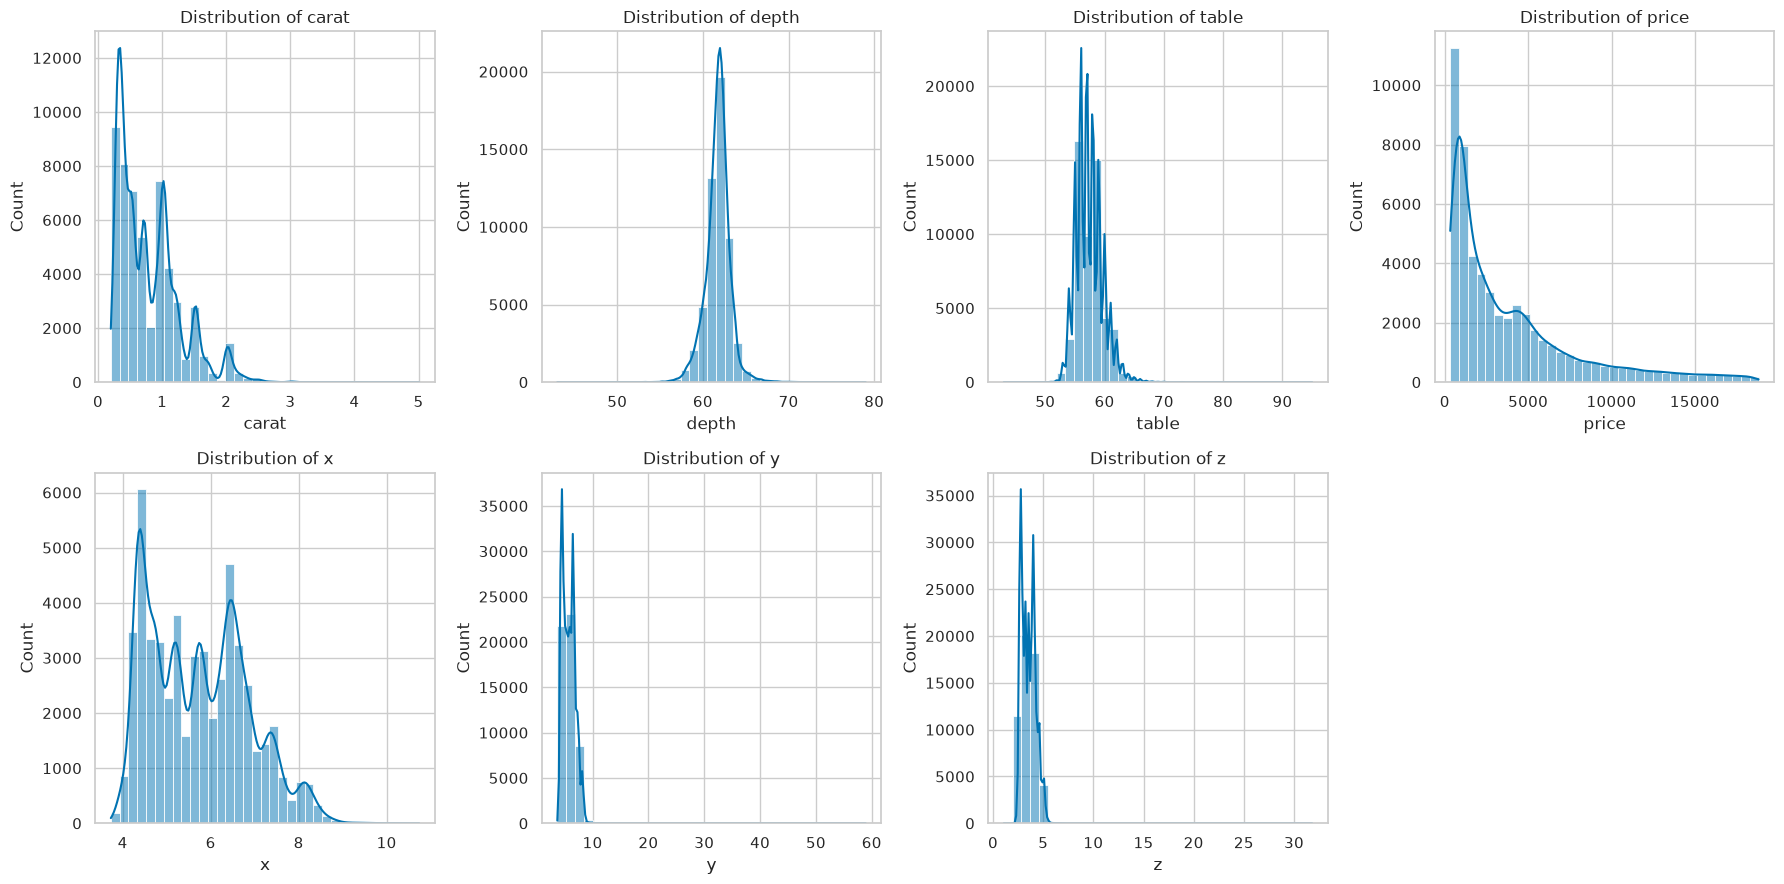

In [7]:
numeric_eda_columns = ["carat", "depth", "table", "price", "x", "y", "z"]
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for axis, column in zip(axes.ravel(), numeric_eda_columns):
    sns.histplot(diamonds_clean[column], bins=35, kde=True, ax=axis)
    axis.set_title(f"Distribution of {column}")
    axis.set_ylabel("Count")

axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()

**Observation.** Price, carat, and the physical dimensions are right-skewed: most diamonds are relatively small and inexpensive, with fewer large, high-price records. The tails are retained because they are valid products and are important for evaluating high-value prediction errors.

<ipython-input-1-f484c6c60f5f>:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


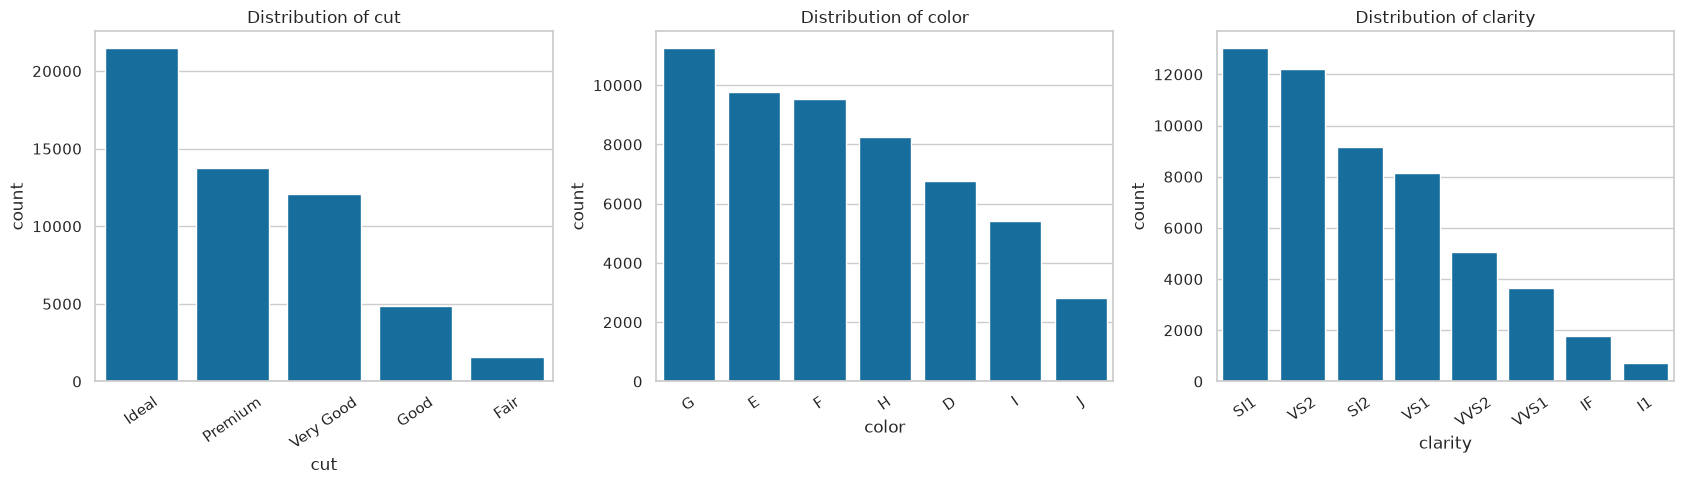

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for axis, column in zip(axes, ["cut", "color", "clarity"]):
    order = diamonds_clean[column].value_counts().index
    sns.countplot(data=diamonds_clean, x=column, order=order, ax=axis)
    axis.set_title(f"Distribution of {column}")
    axis.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

**Observation.** The quality categories are not equally represented. One-hot encoding keeps every observed category available to the models without imposing a false numeric distance between labels.

<ipython-input-1-3c6cbc331762>:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


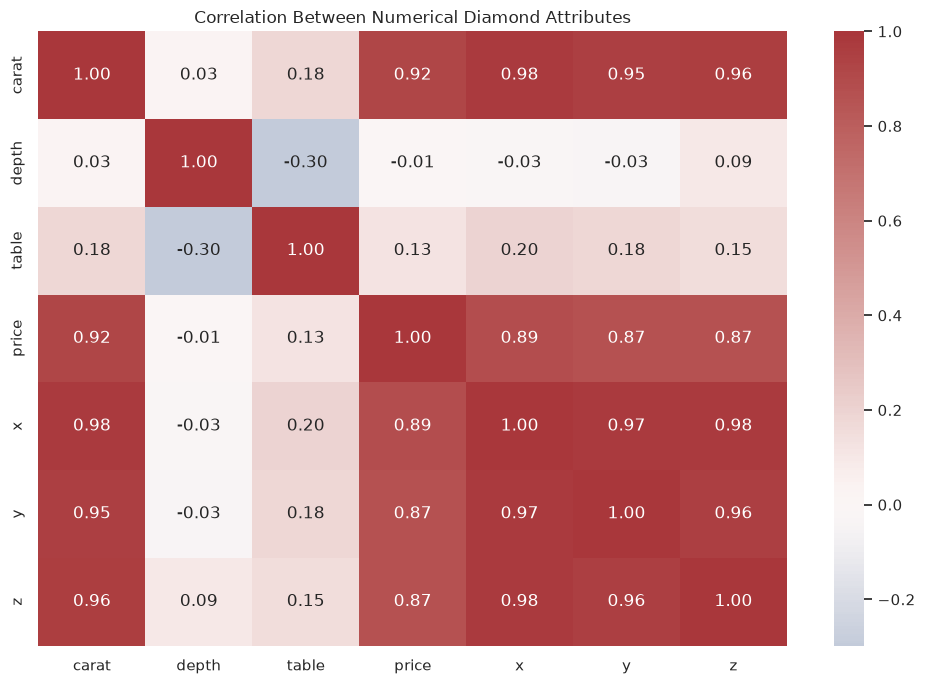

In [9]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    diamonds_clean[numeric_eda_columns].corr(),
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
)
plt.title("Correlation Between Numerical Diamond Attributes")
plt.tight_layout()
plt.show()

**Observation.** Carat and the three dimensions move together and have the clearest positive relationship with price. Their correlation also explains why regularised linear models are worth comparing with ordinary Linear Regression.

<ipython-input-1-d9ce8e5da2c7>:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


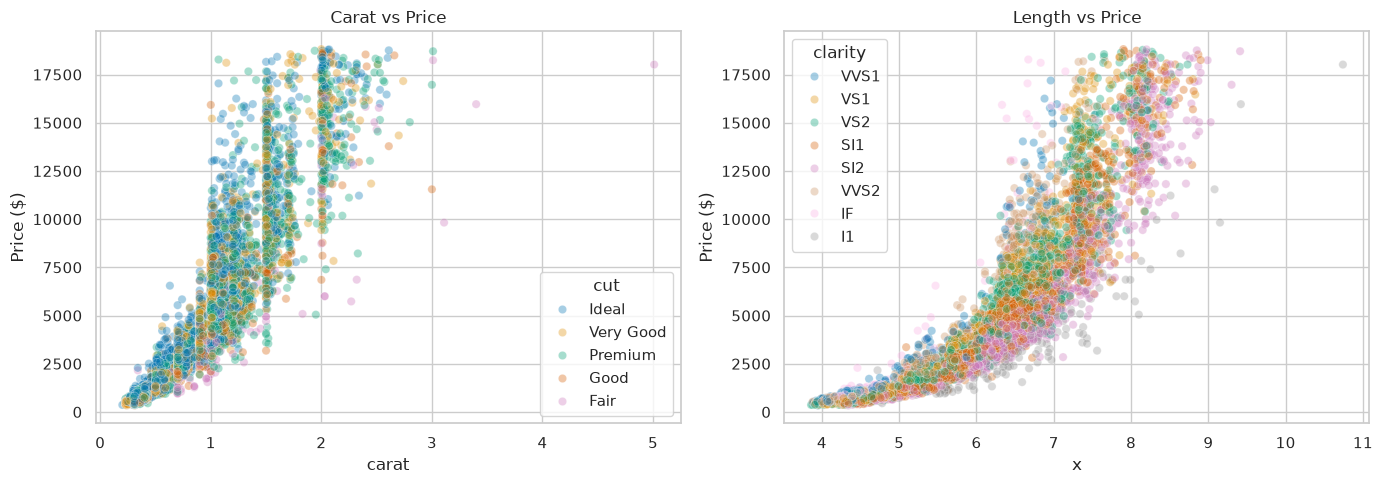

In [10]:
sample_for_scatter = diamonds_clean.sample(
    n=min(10_000, len(diamonds_clean)), random_state=RANDOM_STATE
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(
    data=sample_for_scatter,
    x="carat",
    y="price",
    hue="cut",
    alpha=0.35,
    ax=axes[0],
)
axes[0].set_title("Carat vs Price")
axes[0].set_ylabel("Price ($)")

sns.scatterplot(
    data=sample_for_scatter,
    x="x",
    y="price",
    hue="clarity",
    alpha=0.35,
    ax=axes[1],
)
axes[1].set_title("Length vs Price")
axes[1].set_ylabel("Price ($)")
plt.tight_layout()
plt.show()

**Observation.** Price rises with carat and length, but the spread widens for larger diamonds and quality categories shift the relationship. This supports comparing nonlinear models with the linear baseline.

**Outlier decision.** Large price and size values are plausible diamonds, not data-entry impossibilities. They are kept; only invalid dimensions and exact duplicates are removed.

## 4. Engineer features and define the target

`volume` combines the three measurements into an approximate physical size. `length_width_ratio` captures shape. Both have a direct physical interpretation and may help models learn price differences beyond any one dimension.

In [11]:
diamonds_model = diamonds_clean.copy()
diamonds_model["volume"] = (
    diamonds_model["x"] * diamonds_model["y"] * diamonds_model["z"]
)
diamonds_model["length_width_ratio"] = (
    diamonds_model["x"] / diamonds_model["y"]
)

X = diamonds_model.drop(columns="price")
y = diamonds_model["price"]

numerical_features = X.select_dtypes(include="number").columns.tolist()
categorical_features = X.select_dtypes(exclude="number").columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)
print("Target: price")

Numerical features: ['carat', 'depth', 'table', 'x', 'y', 'z', 'volume', 'length_width_ratio']
Categorical features: ['cut', 'color', 'clarity']
Target: price


## 5. Split and preprocess

The 80/20 split is created once and reused for all ten models. Preprocessing is fitted inside each pipeline using training data only, which prevents leakage.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")

Training rows: 43,020
Test rows: 10,755


### Build the shared preprocessing pipeline

Numerical columns use median imputation and standardisation. Categorical columns use mode imputation and one-hot encoding. Dropping the first level avoids redundant dummy columns for linear models.

In [13]:
numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", numerical_pipeline, numerical_features),
        ("categorical", categorical_pipeline, categorical_features),
    ]
)

## Model 1: Multiple Linear Regression

Linear Regression is the common baseline: it is easy to interpret, but assumes that each transformed feature has a linear additive relationship with price.

### Step 1 — Train the baseline

In [14]:
linear_regression_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression()),
    ]
)

linear_regression_model.fit(X_train, y_train)
print("Linear Regression training complete.")

Linear Regression training complete.


### Step 2 — Evaluate the baseline

- **R²:** proportion of price variation explained; higher is better.
- **RMSE:** error in dollars with extra weight on large misses; lower is better.
- **MAE:** average absolute error in dollars; lower is better.

In [15]:
train_predictions = linear_regression_model.predict(X_train)
test_predictions = linear_regression_model.predict(X_test)

def regression_metrics(actual, predicted):
    return {
        "R2 Score": r2_score(actual, predicted),
        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
        "MAE": mean_absolute_error(actual, predicted),
    }

train_metrics = regression_metrics(y_train, train_predictions)
test_metrics = regression_metrics(y_test, test_predictions)

pd.DataFrame([train_metrics, test_metrics], index=["Training set", "Test set"]).round(3)

Out[0]: 
              R2 Score      RMSE      MAE
Training set     0.921  1122.832  731.312
Test set         0.920  1125.164  735.216


In [16]:
results_df = pd.DataFrame(
    [
        {
            "Model": "Multiple Linear Regression",
            **test_metrics,
        }
    ]
).sort_values("R2 Score", ascending=False, ignore_index=True)

results_df.round(3)

Out[0]: 
                        Model  R2 Score      RMSE      MAE
0  Multiple Linear Regression      0.92  1125.164  735.216


### Step 3 — Check prediction error

Points close to the diagonal indicate accurate predictions. A useful residual plot should be centred near zero without a strong pattern.

<ipython-input-1-07ce7ce2446c>:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


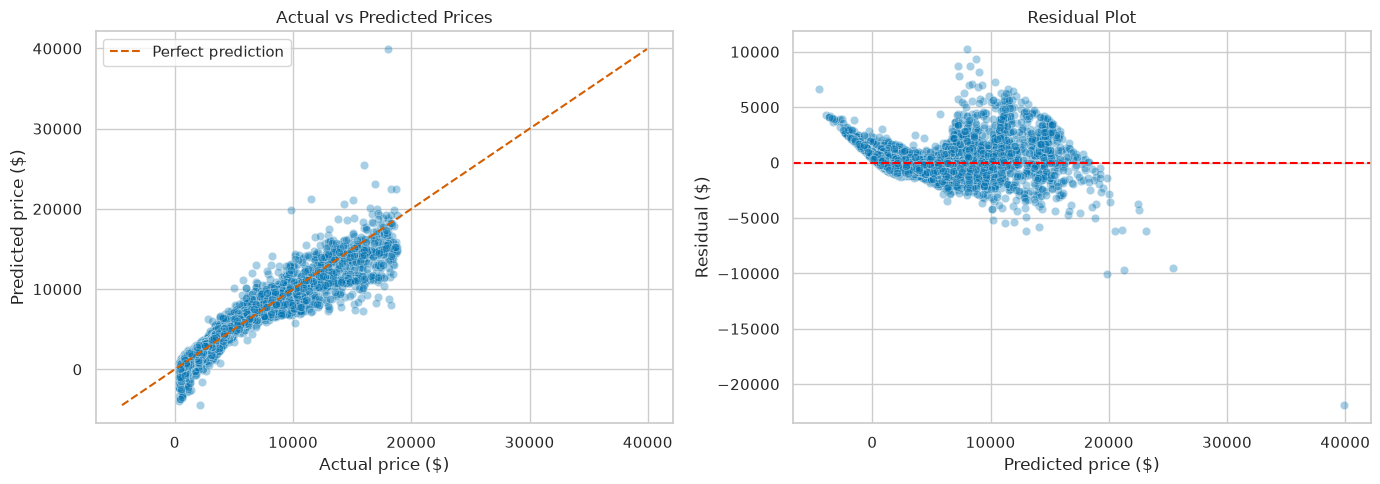

In [17]:
residuals = y_test - test_predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=y_test, y=test_predictions, alpha=0.35, ax=axes[0])
plot_min = min(y_test.min(), test_predictions.min())
plot_max = max(y_test.max(), test_predictions.max())
axes[0].plot([plot_min, plot_max], [plot_min, plot_max], "r--", label="Perfect prediction")
axes[0].set(title="Actual vs Predicted Prices", xlabel="Actual price ($)", ylabel="Predicted price ($)")
axes[0].legend()

sns.scatterplot(x=test_predictions, y=residuals, alpha=0.35, ax=axes[1])
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set(title="Residual Plot", xlabel="Predicted price ($)", ylabel="Residual ($)")

plt.tight_layout()
plt.show()

### Step 4 — Inspect coefficients

For standardised numerical inputs, a coefficient represents a one-standard-deviation change. One-hot coefficients are relative to the dropped category. These are associations, not causal effects.

In [18]:
fitted_preprocessor = linear_regression_model.named_steps["preprocessor"]
feature_names = fitted_preprocessor.get_feature_names_out()
coefficients = linear_regression_model.named_steps["regressor"].coef_

coefficient_table = pd.DataFrame(
    {"Feature": feature_names, "Coefficient": coefficients}
)
coefficient_table["Absolute Coefficient"] = coefficient_table["Coefficient"].abs()
coefficient_table.sort_values("Absolute Coefficient", ascending=False).head(15)

Out[0]: 
                      Feature  Coefficient  Absolute Coefficient
18    categorical__clarity_IF  5414.442325           5414.442325
23  categorical__clarity_VVS1  5068.848817           5068.848817
24  categorical__clarity_VVS2  5011.249935           5011.249935
21   categorical__clarity_VS1  4651.100435           4651.100435
0            numerical__carat  4419.422860           4419.422860
22   categorical__clarity_VS2  4336.735936           4336.735936
19   categorical__clarity_SI1  3747.965634           3747.965634
20   categorical__clarity_SI2  2786.367624           2786.367624
17       categorical__color_J -2379.534938           2379.534938
16       categorical__color_I -1483.849958           1483.849958
4                numerical__y -1135.074625           1135.074625
6           numerical__volume  1119.985108           1119.985108
15       categorical__color_H  -987.525123            987.525123
9      categorical__cut_Ideal   782.170422            782.170422
10   categorical

### Model 1 takeaway

The baseline establishes how far a purely linear relationship can go. The training/test gap and residual shape are more informative than the training score alone.

## Model 2: Ridge Regression

Ridge Regression adds an L2 penalty to Linear Regression. It shrinks large coefficients and can make the model more stable when features are correlated. The regularization strength is controlled by `alpha`: a larger value applies stronger shrinkage.

### Step 1 — Tune and train Ridge Regression

Three-fold cross-validation tests several `alpha` values using only the training set. The value with the lowest cross-validation RMSE is selected automatically.

In [19]:
ridge_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", Ridge()),
    ]
)

ridge_search = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid={"regressor__alpha": np.logspace(-3, 3, 7)},
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=1,
)
ridge_search.fit(X_train, y_train)
ridge_model = ridge_search.best_estimator_

print(f"Best Ridge alpha: {ridge_search.best_params_['regressor__alpha']:.4g}")
print(f"Best cross-validation RMSE: {-ridge_search.best_score_:,.3f}")

Best Ridge alpha: 100
Best cross-validation RMSE: 1,346.386


### Step 2 — Evaluate Ridge Regression

Both training and test metrics are shown to help identify underfitting or overfitting. The test metrics are then added to the shared comparison table.

In [20]:
ridge_train_predictions = ridge_model.predict(X_train)
ridge_test_predictions = ridge_model.predict(X_test)

ridge_train_metrics = regression_metrics(y_train, ridge_train_predictions)
ridge_test_metrics = regression_metrics(y_test, ridge_test_predictions)

pd.DataFrame(
    [ridge_train_metrics, ridge_test_metrics],
    index=["Training set", "Test set"],
).round(3)

Out[0]: 
              R2 Score      RMSE      MAE
Training set     0.915  1159.842  727.537
Test set         0.916  1150.890  727.534


In [21]:
results_df = pd.concat(
    [
        results_df,
        pd.DataFrame([{"Model": "Ridge Regression", **ridge_test_metrics}]),
    ],
    ignore_index=True,
).sort_values("R2 Score", ascending=False, ignore_index=True)

results_df.round(3)

Out[0]: 
                        Model  R2 Score      RMSE      MAE
0  Multiple Linear Regression     0.920  1125.164  735.216
1            Ridge Regression     0.916  1150.890  727.534


### Model 2 takeaway

Ridge tests whether shrinking correlated coefficients improves generalisation. Its test errors should be judged against the unregularised baseline on the same rows.

## Model 3: Lasso Regression

Lasso Regression adds an L1 penalty. In addition to shrinking coefficients, it can reduce some coefficients exactly to zero, effectively selecting a smaller set of useful features.

### Step 1 — Tune and train Lasso Regression

As with Ridge, three-fold cross-validation chooses `alpha` from the training data. `max_iter` is increased to give the optimization algorithm enough iterations to converge.

In [22]:
lasso_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", Lasso(max_iter=20_000)),
    ]
)

lasso_search = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid={"regressor__alpha": np.logspace(-2, 3, 7)},
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=1,
)
lasso_search.fit(X_train, y_train)
lasso_model = lasso_search.best_estimator_

print(f"Best Lasso alpha: {lasso_search.best_params_['regressor__alpha']:.4g}")
print(f"Best cross-validation RMSE: {-lasso_search.best_score_:,.3f}")

Best Lasso alpha: 3.162
Best cross-validation RMSE: 1,484.537


/home/chifuyu/College/3rd Year/5th SEM/ML/ml-capstone/.venv/lib64/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:842: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.611985e+10, tolerance: 4.536e+07
  model = cd_fast.enet_coordinate_descent(
/home/chifuyu/College/3rd Year/5th SEM/ML/ml-capstone/.venv/lib64/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:842: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.095912e+10, tolerance: 4.536e+07
  model = cd_fast.enet_coordinate_descent(
/home/chifuyu/College/3rd Year/5th SEM/ML/ml-capstone/.venv/lib64/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:842: ConvergenceWarning: Objective did not converge. You mi

### Step 2 — Evaluate Lasso Regression

In [23]:
lasso_train_predictions = lasso_model.predict(X_train)
lasso_test_predictions = lasso_model.predict(X_test)

lasso_train_metrics = regression_metrics(y_train, lasso_train_predictions)
lasso_test_metrics = regression_metrics(y_test, lasso_test_predictions)

pd.DataFrame(
    [lasso_train_metrics, lasso_test_metrics],
    index=["Training set", "Test set"],
).round(3)

Out[0]: 
              R2 Score      RMSE      MAE
Training set     0.918  1143.158  727.187
Test set         0.918  1137.872  727.181


In [24]:
results_df = pd.concat(
    [
        results_df,
        pd.DataFrame([{"Model": "Lasso Regression", **lasso_test_metrics}]),
    ],
    ignore_index=True,
).sort_values("R2 Score", ascending=False, ignore_index=True)

results_df.round(3)

Out[0]: 
                        Model  R2 Score      RMSE      MAE
0  Multiple Linear Regression     0.920  1125.164  735.216
1            Lasso Regression     0.918  1137.872  727.181
2            Ridge Regression     0.916  1150.890  727.534


### Step 3 — Inspect Lasso feature selection

The table lists the coefficients retained by Lasso. Features assigned a coefficient of zero were excluded by regularization.

In [25]:
lasso_feature_names = lasso_model.named_steps["preprocessor"].get_feature_names_out()
lasso_coefficients = lasso_model.named_steps["regressor"].coef_
lasso_coefficient_table = pd.DataFrame(
    {"Feature": lasso_feature_names, "Coefficient": lasso_coefficients}
)
selected_features = lasso_coefficient_table.loc[
    lasso_coefficient_table["Coefficient"] != 0
].copy()
selected_features["Absolute Coefficient"] = selected_features["Coefficient"].abs()

print(f"Features available after preprocessing: {len(lasso_coefficients)}")
print(f"Features retained by Lasso: {len(selected_features)}")
selected_features.sort_values("Absolute Coefficient", ascending=False)

Features available after preprocessing: 25
Features retained by Lasso: 24
Out[0]: 
                          Feature  Coefficient  Absolute Coefficient
0                numerical__carat  4428.696599           4428.696599
18        categorical__clarity_IF  3648.761378           3648.761378
23      categorical__clarity_VVS1  3363.902883           3363.902883
24      categorical__clarity_VVS2  3331.690737           3331.690737
21       categorical__clarity_VS1  2980.792792           2980.792792
22       categorical__clarity_VS2  2692.466820           2692.466820
17           categorical__color_J -2121.208137           2121.208137
19       categorical__clarity_SI1  2114.161411           2114.161411
16           categorical__color_I -1265.646911           1265.646911
20       categorical__clarity_SI2  1166.703546           1166.703546
4                    numerical__y  -933.389700            933.389700
6               numerical__volume   894.890247            894.890247
15           categor

## Comparison of Models 1–3

The best model should have the highest test R² and the lowest test RMSE and MAE. Since all three models use the same data split, their results are directly comparable.

<ipython-input-1-eeca998256b6>:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


                        Model  R2 Score      RMSE      MAE
0  Multiple Linear Regression     0.920  1125.164  735.216
1            Lasso Regression     0.918  1137.872  727.181
2            Ridge Regression     0.916  1150.890  727.534

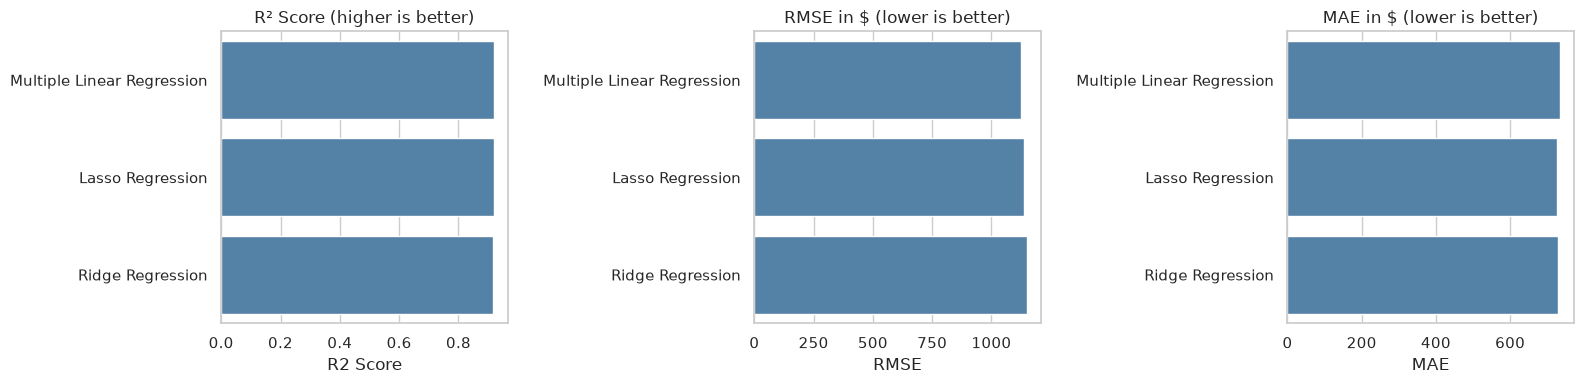

In [26]:
display(results_df.round(3))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
metric_config = [
    ("R2 Score", "R² Score (higher is better)"),
    ("RMSE", "RMSE in $ (lower is better)"),
    ("MAE", "MAE in $ (lower is better)"),
]

for axis, (metric, title) in zip(axes, metric_config):
    sns.barplot(data=results_df, x=metric, y="Model", ax=axis, color="steelblue")
    axis.set_title(title)
    axis.set_ylabel("")

plt.tight_layout()
plt.show()

### Model 3 takeaway

Lasso trades some flexibility for a smaller coefficient set. The retained-feature count shows whether that simplification costs predictive performance.

## Model 4: ElasticNet Regression

ElasticNet combines L1 regularization from Lasso with L2 regularization from Ridge. This allows it to shrink coefficients, remove weak features, and remain more stable when predictors are correlated.

### Step 1 — Tune `alpha` and `l1_ratio`

`alpha` controls the overall regularization strength. `l1_ratio` controls the mixture: values near 1 behave more like Lasso, while values near 0 behave more like Ridge. Three-fold cross-validation chooses the combination with the lowest validation RMSE using only the training set.

In [27]:
elastic_net_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "regressor",
            ElasticNet(max_iter=20_000, random_state=RANDOM_STATE),
        ),
    ]
)

elastic_net_search = GridSearchCV(
    estimator=elastic_net_pipeline,
    param_grid={
        "regressor__alpha": [0.001, 0.01, 0.1, 1.0, 10.0],
        "regressor__l1_ratio": [0.1, 0.5, 0.9],
    },
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=1,
)
elastic_net_search.fit(X_train, y_train)
elastic_net_model = elastic_net_search.best_estimator_

print("Best ElasticNet parameters:", elastic_net_search.best_params_)
print(f"Best cross-validation RMSE: {-elastic_net_search.best_score_:,.3f}")

Best ElasticNet parameters: {'regressor__alpha': 0.01, 'regressor__l1_ratio': 0.5}
Best cross-validation RMSE: 1,338.960


/home/chifuyu/College/3rd Year/5th SEM/ML/ml-capstone/.venv/lib64/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:842: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.269285e+10, tolerance: 4.536e+07
  model = cd_fast.enet_coordinate_descent(


### Step 2 — Evaluate ElasticNet

In [28]:
elastic_train_predictions = elastic_net_model.predict(X_train)
elastic_test_predictions = elastic_net_model.predict(X_test)

elastic_train_metrics = regression_metrics(y_train, elastic_train_predictions)
elastic_test_metrics = regression_metrics(y_test, elastic_test_predictions)

pd.DataFrame(
    [elastic_train_metrics, elastic_test_metrics],
    index=["Training set", "Test set"],
).round(3)

Out[0]: 
              R2 Score      RMSE      MAE
Training set     0.911  1190.010  735.948
Test set         0.912  1178.094  735.102


In [29]:
results_df = pd.concat(
    [
        results_df,
        pd.DataFrame([{"Model": "ElasticNet Regression", **elastic_test_metrics}]),
    ],
    ignore_index=True,
).sort_values("R2 Score", ascending=False, ignore_index=True)

results_df.round(3)

Out[0]: 
                        Model  R2 Score      RMSE      MAE
0  Multiple Linear Regression     0.920  1125.164  735.216
1            Lasso Regression     0.918  1137.872  727.181
2            Ridge Regression     0.916  1150.890  727.534
3       ElasticNet Regression     0.912  1178.094  735.102


### Step 3 — Inspect coefficient sparsity

The L1 component can set coefficients exactly to zero. This cell reports how many transformed features ElasticNet retained and displays the strongest coefficients.

In [30]:
elastic_feature_names = elastic_net_model.named_steps["preprocessor"].get_feature_names_out()
elastic_coefficients = elastic_net_model.named_steps["regressor"].coef_
elastic_coefficient_table = pd.DataFrame(
    {"Feature": elastic_feature_names, "Coefficient": elastic_coefficients}
)
elastic_coefficient_table["Absolute Coefficient"] = (
    elastic_coefficient_table["Coefficient"].abs()
)
elastic_selected_features = elastic_coefficient_table.loc[
    elastic_coefficient_table["Coefficient"] != 0
]

print(f"Features available after preprocessing: {len(elastic_coefficients)}")
print(f"Features retained by ElasticNet: {len(elastic_selected_features)}")
elastic_selected_features.sort_values(
    "Absolute Coefficient", ascending=False
).head(15)

Features available after preprocessing: 25
Features retained by ElasticNet: 25
Out[0]: 
                      Feature  Coefficient  Absolute Coefficient
0            numerical__carat  3643.988610           3643.988610
17       categorical__color_J -1904.880941           1904.880941
18    categorical__clarity_IF  1892.935946           1892.935946
24  categorical__clarity_VVS2  1724.679381           1724.679381
23  categorical__clarity_VVS1  1724.278348           1724.278348
21   categorical__clarity_VS1  1403.811876           1403.811876
6           numerical__volume  1402.168869           1402.168869
4                numerical__y -1254.778543           1254.778543
16       categorical__color_I -1164.700053           1164.700053
22   categorical__clarity_VS2  1144.192593           1144.192593
15       categorical__color_H  -745.749286            745.749286
9      categorical__cut_Ideal   669.584230            669.584230
10   categorical__cut_Premium   595.540307            595.540307
19

### Model 4 takeaway

ElasticNet combines Ridge-style stability with Lasso-style sparsity. Its selected `l1_ratio` indicates which type of penalty the validation folds preferred.

## Model 5: Polynomial Regression

Polynomial Regression applies `PolynomialFeatures` before Linear Regression. This creates squared terms and pairwise interactions, allowing a linear estimator to represent curved and interacting relationships.

### Step 1 — Compare polynomial degrees

Degrees 1 and 2 are compared on a validation split created from the training data. Degree 1 reproduces an ordinary linear relationship; degree 2 adds squared and interaction terms. Degree 3 is intentionally excluded because one-hot expansion followed by cubic expansion would create thousands of dense features and excessive memory use.

In [31]:
X_poly_train, X_poly_validation, y_poly_train, y_poly_validation = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

polynomial_candidates = {}
polynomial_degree_rows = []

for degree in [1, 2]:
    candidate_model = Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("polynomial_features", PolynomialFeatures(degree=degree, include_bias=False)),
            ("regressor", LinearRegression()),
        ]
    )
    candidate_model.fit(X_poly_train, y_poly_train)
    validation_predictions = candidate_model.predict(X_poly_validation)
    validation_metrics = regression_metrics(y_poly_validation, validation_predictions)
    polynomial_candidates[degree] = candidate_model
    polynomial_degree_rows.append(
        {"Degree": degree, **validation_metrics}
    )

polynomial_degree_results = pd.DataFrame(polynomial_degree_rows).sort_values(
    "RMSE", ignore_index=True
)
best_polynomial_degree = int(polynomial_degree_results.loc[0, "Degree"])
print(f"Selected polynomial degree: {best_polynomial_degree}")
display(polynomial_degree_results.round(3))

Selected polynomial degree: 1


   Degree  R2 Score        RMSE       MAE
0       1     0.840    1599.608   744.721
1       2 -5781.241  304561.924  3684.137

### Step 2 — Refit Polynomial Regression on the full training set

In [32]:
polynomial_model = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "polynomial_features",
            PolynomialFeatures(degree=best_polynomial_degree, include_bias=False),
        ),
        ("regressor", LinearRegression()),
    ]
)
polynomial_model.fit(X_train, y_train)
generated_feature_count = polynomial_model.named_steps[
    "polynomial_features"
].n_output_features_
print(f"Generated polynomial features: {generated_feature_count:,}")

Generated polynomial features: 25


### Step 3 — Evaluate Polynomial Regression

In [33]:
polynomial_train_predictions = polynomial_model.predict(X_train)
polynomial_test_predictions = polynomial_model.predict(X_test)

polynomial_train_metrics = regression_metrics(y_train, polynomial_train_predictions)
polynomial_test_metrics = regression_metrics(y_test, polynomial_test_predictions)

pd.DataFrame(
    [polynomial_train_metrics, polynomial_test_metrics],
    index=["Training set", "Test set"],
).round(3)

Out[0]: 
              R2 Score      RMSE      MAE
Training set     0.921  1122.832  731.312
Test set         0.920  1125.164  735.216


In [34]:
results_df = pd.concat(
    [
        results_df,
        pd.DataFrame(
            [{"Model": "Polynomial Regression", **polynomial_test_metrics}]
        ),
    ],
    ignore_index=True,
).sort_values("R2 Score", ascending=False, ignore_index=True)

results_df.round(3)

Out[0]: 
                        Model  R2 Score      RMSE      MAE
0  Multiple Linear Regression     0.920  1125.164  735.216
1       Polynomial Regression     0.920  1125.164  735.216
2            Lasso Regression     0.918  1137.872  727.181
3            Ridge Regression     0.916  1150.890  727.534
4       ElasticNet Regression     0.912  1178.094  735.102


### Step 4 — Plot Polynomial Regression predictions and residuals

<ipython-input-1-19d9cf9246e3>:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


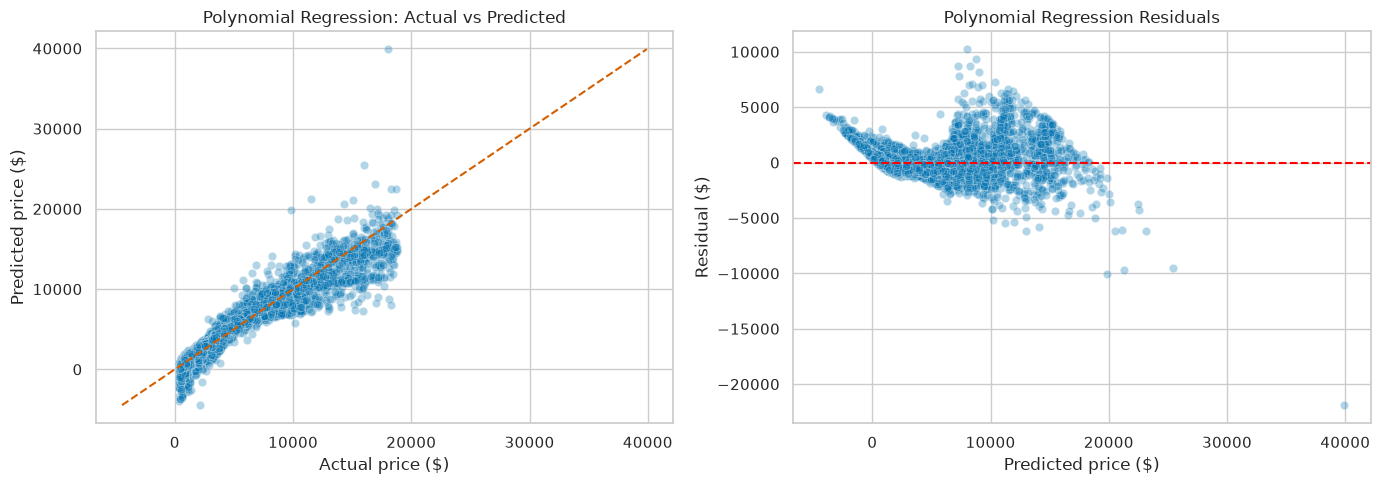

In [35]:
polynomial_residuals = y_test - polynomial_test_predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=y_test, y=polynomial_test_predictions, alpha=0.3, ax=axes[0])
plot_min = min(y_test.min(), polynomial_test_predictions.min())
plot_max = max(y_test.max(), polynomial_test_predictions.max())
axes[0].plot([plot_min, plot_max], [plot_min, plot_max], "r--")
axes[0].set(
    title="Polynomial Regression: Actual vs Predicted",
    xlabel="Actual price ($)",
    ylabel="Predicted price ($)",
)
sns.scatterplot(
    x=polynomial_test_predictions, y=polynomial_residuals, alpha=0.3, ax=axes[1]
)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set(
    title="Polynomial Regression Residuals",
    xlabel="Predicted price ($)",
    ylabel="Residual ($)",
)
plt.tight_layout()
plt.show()

### Model 5 takeaway

Polynomial terms allow curves and interactions while keeping a linear estimator. Validation error determines whether the added degree improves the model or merely adds complexity.

## Model 6: Decision Tree Regressor

A Decision Tree repeatedly splits the feature space into regions and predicts a price from the training diamonds in each final region. Unlike the first three models, it can learn nonlinear relationships and interactions without requiring polynomial features.

### Step 1 — Tune and train the Decision Tree

An unrestricted tree can memorize its training data. Three-fold cross-validation therefore selects the tree depth and minimum leaf size that give the lowest validation RMSE. `clone(preprocessor)` creates an independent preprocessing copy for this model.

In [36]:
decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        ("regressor", DecisionTreeRegressor(random_state=RANDOM_STATE)),
    ]
)

decision_tree_search = GridSearchCV(
    estimator=decision_tree_pipeline,
    param_grid={
        "regressor__max_depth": [8, 12, 16, None],
        "regressor__min_samples_leaf": [1, 2, 5],
    },
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=1,
)
decision_tree_search.fit(X_train, y_train)
decision_tree_model = decision_tree_search.best_estimator_

print("Best Decision Tree parameters:", decision_tree_search.best_params_)
print(f"Best cross-validation RMSE: {-decision_tree_search.best_score_:,.3f}")

Best Decision Tree parameters: {'regressor__max_depth': 16, 'regressor__min_samples_leaf': 2}
Best cross-validation RMSE: 839.519


### Step 2 — Evaluate the Decision Tree

A much better training score than test score indicates overfitting. The selected depth and number of leaves help explain the fitted tree's complexity.

In [37]:
tree_train_predictions = decision_tree_model.predict(X_train)
tree_test_predictions = decision_tree_model.predict(X_test)

tree_train_metrics = regression_metrics(y_train, tree_train_predictions)
tree_test_metrics = regression_metrics(y_test, tree_test_predictions)
fitted_tree = decision_tree_model.named_steps["regressor"]

print(f"Fitted tree depth: {fitted_tree.get_depth()}")
print(f"Number of leaf nodes: {fitted_tree.get_n_leaves():,}")
pd.DataFrame(
    [tree_train_metrics, tree_test_metrics],
    index=["Training set", "Test set"],
).round(3)

Fitted tree depth: 16
Number of leaf nodes: 6,687
Out[0]: 
              R2 Score     RMSE      MAE
Training set     0.989  427.512  192.406
Test set         0.963  766.689  361.614


In [38]:
results_df = pd.concat(
    [
        results_df,
        pd.DataFrame([{"Model": "Decision Tree Regression", **tree_test_metrics}]),
    ],
    ignore_index=True,
).sort_values("R2 Score", ascending=False, ignore_index=True)

results_df.round(3)

Out[0]: 
                        Model  R2 Score      RMSE      MAE
0    Decision Tree Regression     0.963   766.689  361.614
1  Multiple Linear Regression     0.920  1125.164  735.216
2       Polynomial Regression     0.920  1125.164  735.216
3            Lasso Regression     0.918  1137.872  727.181
4            Ridge Regression     0.916  1150.890  727.534
5       ElasticNet Regression     0.912  1178.094  735.102


### Step 3 — Inspect Decision Tree feature importance

The required feature-importance analysis shows which transformed inputs produced the largest total reductions in squared error across the fitted tree. Correlated features can divide importance between themselves, so these values should be interpreted as model diagnostics rather than causal effects.

In [39]:
tree_feature_names = decision_tree_model.named_steps["preprocessor"].get_feature_names_out()
tree_importance = pd.DataFrame(
    {
        "Feature": tree_feature_names,
        "Importance": fitted_tree.feature_importances_,
    }
).sort_values("Importance", ascending=False, ignore_index=True)

tree_importance.head(15)

Out[0]: 
                          Feature  Importance
0               numerical__volume    0.637442
1                    numerical__y    0.213403
2                numerical__carat    0.044974
3        categorical__clarity_SI2    0.020232
4        categorical__clarity_SI1    0.014028
5            categorical__color_J    0.010994
6            categorical__color_I    0.008504
7            categorical__color_H    0.006633
8       categorical__clarity_VVS1    0.005243
9        categorical__clarity_VS2    0.005150
10      categorical__clarity_VVS2    0.005025
11        categorical__clarity_IF    0.004848
12  numerical__length_width_ratio    0.003603
13                   numerical__z    0.003379
14                   numerical__x    0.003321


<ipython-input-1-ed6f53fcc26b>:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


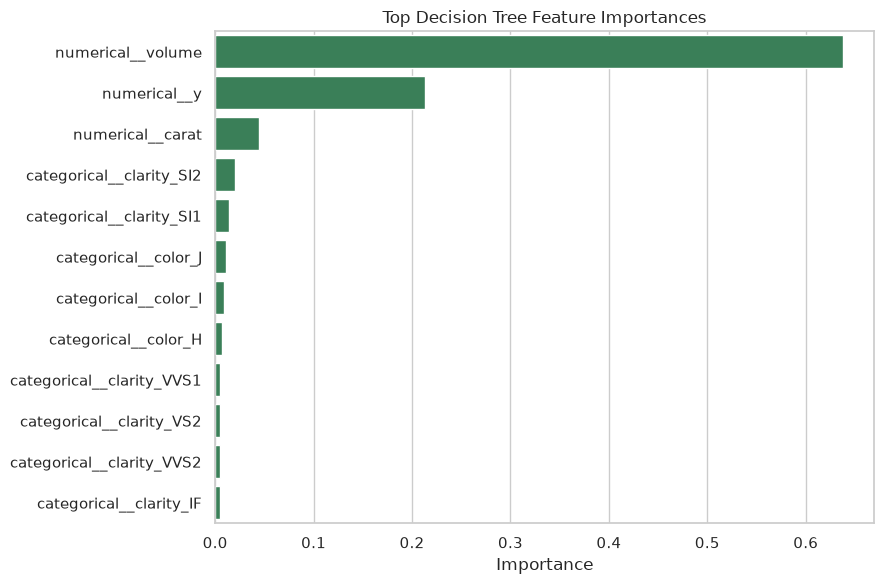

In [40]:
plt.figure(figsize=(9, 6))
sns.barplot(
    data=tree_importance.head(12),
    x="Importance",
    y="Feature",
    color="seagreen",
)
plt.title("Top Decision Tree Feature Importances")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Model 6 takeaway

The tree can learn nonlinear thresholds without assuming a price equation. Comparing its training and test errors reveals whether the selected depth still overfits.

## Model 7: Random Forest Regressor

A Random Forest trains many decision trees on bootstrapped samples and averages their predictions. Random feature subsets make the trees less correlated, usually improving generalization and stability over one Decision Tree.

### Step 1 — Tune `n_estimators` and train the Random Forest

The required `n_estimators` tuning compares forests containing 100, 200, and 300 trees. `oob_score=True` evaluates each candidate using training rows that were excluded from individual bootstrap samples, so the test set remains untouched during selection. The candidate with the highest out-of-bag R² is retained.

In [41]:
forest_candidates = {}
forest_tuning_rows = []

for number_of_trees in [100, 200, 300]:
    candidate_model = Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            (
                "regressor",
                RandomForestRegressor(
                    n_estimators=number_of_trees,
                    min_samples_leaf=1,
                    max_features=1.0,
                    bootstrap=True,
                    oob_score=True,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    )
    candidate_model.fit(X_train, y_train)
    candidate_oob_r2 = candidate_model.named_steps["regressor"].oob_score_
    forest_candidates[number_of_trees] = candidate_model
    forest_tuning_rows.append(
        {"n_estimators": number_of_trees, "OOB R2 Score": candidate_oob_r2}
    )

forest_tuning_results = pd.DataFrame(forest_tuning_rows).sort_values(
    "OOB R2 Score", ascending=False, ignore_index=True
)
best_n_estimators = int(forest_tuning_results.loc[0, "n_estimators"])
random_forest_model = forest_candidates[best_n_estimators]
fitted_forest = random_forest_model.named_steps["regressor"]

print(f"Selected n_estimators: {best_n_estimators}")
display(forest_tuning_results.round(4))

Selected n_estimators: 300


   n_estimators  OOB R2 Score
0           300        0.9742
1           200        0.9739
2           100        0.9735

### Step 2 — Evaluate the Random Forest

In [42]:
forest_train_predictions = random_forest_model.predict(X_train)
forest_test_predictions = random_forest_model.predict(X_test)

forest_train_metrics = regression_metrics(y_train, forest_train_predictions)
forest_test_metrics = regression_metrics(y_test, forest_test_predictions)

pd.DataFrame(
    [forest_train_metrics, forest_test_metrics],
    index=["Training set", "Test set"],
).round(3)

Out[0]: 
              R2 Score     RMSE      MAE
Training set     0.996  236.594  108.443
Test set         0.976  619.896  295.415


In [43]:
results_df = pd.concat(
    [
        results_df,
        pd.DataFrame([{"Model": "Random Forest Regression", **forest_test_metrics}]),
    ],
    ignore_index=True,
).sort_values("R2 Score", ascending=False, ignore_index=True)

results_df.round(3)

Out[0]: 
                        Model  R2 Score      RMSE      MAE
0    Random Forest Regression     0.976   619.896  295.415
1    Decision Tree Regression     0.963   766.689  361.614
2  Multiple Linear Regression     0.920  1125.164  735.216
3       Polynomial Regression     0.920  1125.164  735.216
4            Lasso Regression     0.918  1137.872  727.181
5            Ridge Regression     0.916  1150.890  727.534
6       ElasticNet Regression     0.912  1178.094  735.102


### Step 3 — Inspect Random Forest feature importance

Impurity-based importance measures how much each transformed feature contributes to reducing prediction error across the forest. It is useful for interpretation, although correlated features may share importance.

In [44]:
forest_feature_names = random_forest_model.named_steps["preprocessor"].get_feature_names_out()
forest_importance = pd.DataFrame(
    {
        "Feature": forest_feature_names,
        "Importance": fitted_forest.feature_importances_,
    }
).sort_values("Importance", ascending=False, ignore_index=True)

forest_importance.head(15)

Out[0]: 
                          Feature  Importance
0               numerical__volume    0.695730
1                    numerical__y    0.164465
2                numerical__carat    0.028760
3        categorical__clarity_SI2    0.019761
4        categorical__clarity_SI1    0.013344
5            categorical__color_J    0.011031
6            categorical__color_I    0.008431
7            categorical__color_H    0.006901
8                    numerical__x    0.005750
9   numerical__length_width_ratio    0.005230
10      categorical__clarity_VVS2    0.005021
11               numerical__depth    0.005007
12       categorical__clarity_VS2    0.004668
13        categorical__clarity_IF    0.004662
14      categorical__clarity_VVS1    0.004541


<ipython-input-1-ea37f026ad77>:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


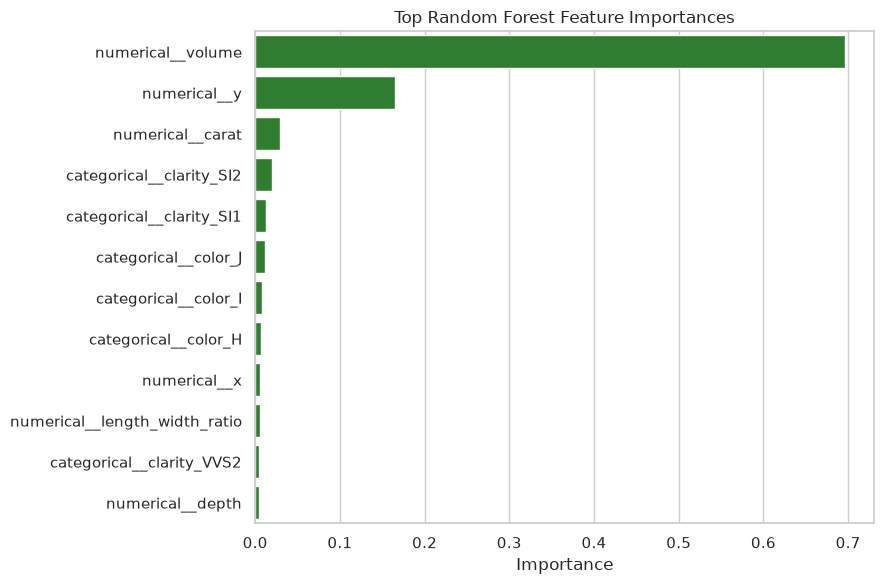

In [45]:
plt.figure(figsize=(9, 6))
sns.barplot(
    data=forest_importance.head(12),
    x="Importance",
    y="Feature",
    color="forestgreen",
)
plt.title("Top Random Forest Feature Importances")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Comparison of Models 1–7

All seven models use the same cleaned observations and test set. Rank them primarily by test R² while also checking RMSE, MAE, and the difference between training and test performance.

<ipython-input-1-e10b7725f550>:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


                        Model  R2 Score      RMSE      MAE
0    Random Forest Regression     0.976   619.896  295.415
1    Decision Tree Regression     0.963   766.689  361.614
2  Multiple Linear Regression     0.920  1125.164  735.216
3       Polynomial Regression     0.920  1125.164  735.216
4            Lasso Regression     0.918  1137.872  727.181
5            Ridge Regression     0.916  1150.890  727.534
6       ElasticNet Regression     0.912  1178.094  735.102

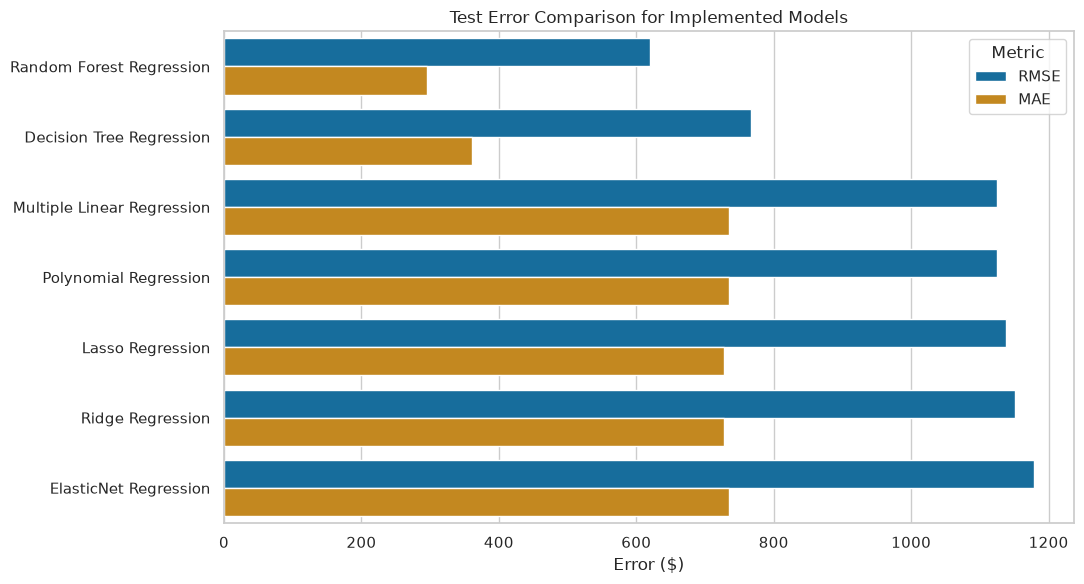

In [46]:
display(results_df.round(3))

comparison_long = results_df.melt(
    id_vars="Model",
    value_vars=["RMSE", "MAE"],
    var_name="Metric",
    value_name="Error ($)",
)
plt.figure(figsize=(11, 6))
sns.barplot(data=comparison_long, x="Error ($)", y="Model", hue="Metric")
plt.title("Test Error Comparison for Implemented Models")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Model 7 takeaway

The forest reduces the variance of a single tree by averaging many trees. Similar out-of-bag and test R² values would support a stable generalisation estimate.

## Model 8: Gradient Boosting Regressor

Gradient Boosting builds shallow decision trees sequentially. Each new tree learns to correct errors made by the existing ensemble, allowing the model to capture complex nonlinear relationships in diamond prices.

### Step 1 — Tune the learning rate

Following the required algorithm notes, `learning_rate` is tuned. Twenty percent of the existing training set is used as a temporary validation set. The test set remains untouched, preventing test-data leakage during model selection.

In [47]:
X_boost_train, X_boost_validation, y_boost_train, y_boost_validation = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

boosting_candidates = {}
boosting_tuning_rows = []

for learning_rate in [0.03, 0.05, 0.10]:
    candidate_model = Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            (
                "regressor",
                GradientBoostingRegressor(
                    n_estimators=250,
                    learning_rate=learning_rate,
                    max_depth=3,
                    min_samples_leaf=3,
                    subsample=0.8,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )
    candidate_model.fit(X_boost_train, y_boost_train)
    validation_predictions = candidate_model.predict(X_boost_validation)
    validation_rmse = np.sqrt(
        mean_squared_error(y_boost_validation, validation_predictions)
    )
    boosting_candidates[learning_rate] = candidate_model
    boosting_tuning_rows.append(
        {"learning_rate": learning_rate, "Validation RMSE": validation_rmse}
    )

boosting_tuning_results = pd.DataFrame(boosting_tuning_rows).sort_values(
    "Validation RMSE", ignore_index=True
)
best_learning_rate = float(boosting_tuning_results.loc[0, "learning_rate"])
print(f"Selected learning_rate: {best_learning_rate}")
display(boosting_tuning_results.round(3))

Selected learning_rate: 0.1


   learning_rate  Validation RMSE
0           0.10          779.015
1           0.05          855.216
2           0.03          925.938

### Step 2 — Refit Gradient Boosting on the full training set

After selecting the learning rate, a fresh model is trained using every row in the original training split.

In [48]:
gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "regressor",
            GradientBoostingRegressor(
                n_estimators=250,
                learning_rate=best_learning_rate,
                max_depth=3,
                min_samples_leaf=3,
                subsample=0.8,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
gradient_boosting_model.fit(X_train, y_train)
print("Gradient Boosting training complete.")

Gradient Boosting training complete.


### Step 3 — Evaluate Gradient Boosting

In [49]:
boosting_train_predictions = gradient_boosting_model.predict(X_train)
boosting_test_predictions = gradient_boosting_model.predict(X_test)

boosting_train_metrics = regression_metrics(y_train, boosting_train_predictions)
boosting_test_metrics = regression_metrics(y_test, boosting_test_predictions)

pd.DataFrame(
    [boosting_train_metrics, boosting_test_metrics],
    index=["Training set", "Test set"],
).round(3)

Out[0]: 
              R2 Score     RMSE      MAE
Training set     0.969  703.654  364.950
Test set         0.964  751.938  384.848


In [50]:
results_df = pd.concat(
    [
        results_df,
        pd.DataFrame(
            [{"Model": "Gradient Boosting Regressor", **boosting_test_metrics}]
        ),
    ],
    ignore_index=True,
).sort_values("R2 Score", ascending=False, ignore_index=True)

results_df.round(3)

Out[0]: 
                         Model  R2 Score      RMSE      MAE
0     Random Forest Regression     0.976   619.896  295.415
1  Gradient Boosting Regressor     0.964   751.938  384.848
2     Decision Tree Regression     0.963   766.689  361.614
3   Multiple Linear Regression     0.920  1125.164  735.216
4        Polynomial Regression     0.920  1125.164  735.216
5             Lasso Regression     0.918  1137.872  727.181
6             Ridge Regression     0.916  1150.890  727.534
7        ElasticNet Regression     0.912  1178.094  735.102


### Step 4 — Inspect learning progress and feature importance

Training deviance shows how the ensemble's loss changes as trees are added. The feature-importance plot identifies the transformed inputs used most strongly by the fitted ensemble.

Out[0]: 
                      Feature  Importance
0           numerical__volume    0.434656
1                numerical__y    0.426767
2            numerical__carat    0.042736
3                numerical__z    0.022082
4    categorical__clarity_SI2    0.015713
5   categorical__clarity_VVS2    0.008845
6        categorical__color_J    0.008661
7     categorical__clarity_IF    0.005750
8        categorical__color_I    0.005707
9   categorical__clarity_VVS1    0.005301
10               numerical__x    0.003902
11   categorical__clarity_VS1    0.003537
12       categorical__color_H    0.003232
13   categorical__clarity_SI1    0.002989
14   categorical__clarity_VS2    0.002592


<ipython-input-1-73a8363b2250>:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


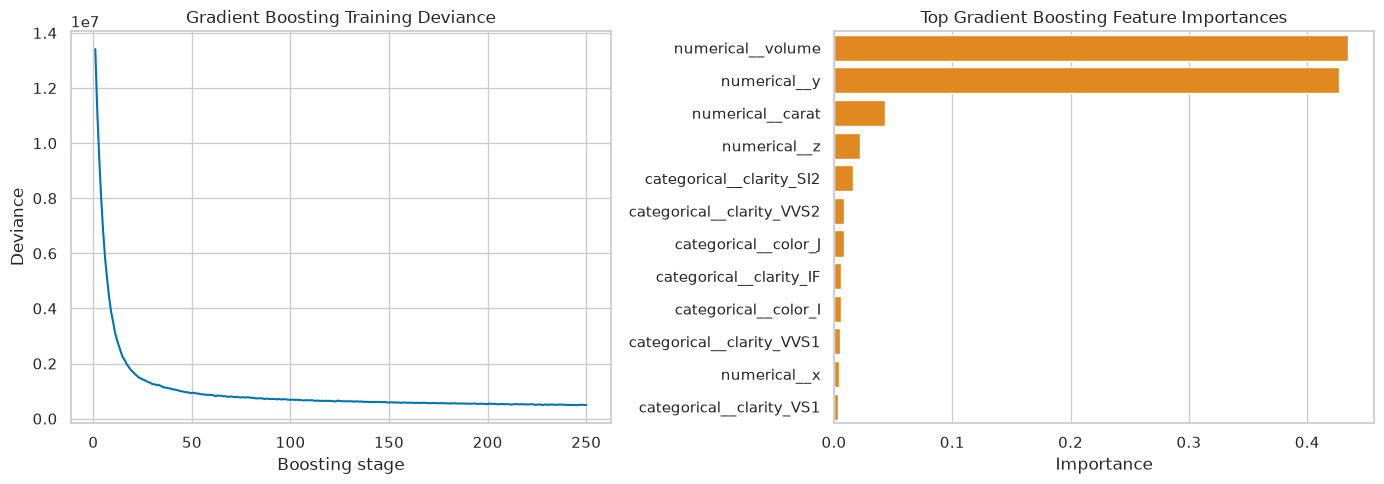

In [51]:
fitted_boosting = gradient_boosting_model.named_steps["regressor"]
boosting_feature_names = gradient_boosting_model.named_steps["preprocessor"].get_feature_names_out()
boosting_importance = pd.DataFrame(
    {
        "Feature": boosting_feature_names,
        "Importance": fitted_boosting.feature_importances_,
    }
).sort_values("Importance", ascending=False, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(
    np.arange(1, fitted_boosting.n_estimators_ + 1),
    fitted_boosting.train_score_,
)
axes[0].set(
    title="Gradient Boosting Training Deviance",
    xlabel="Boosting stage",
    ylabel="Deviance",
)
sns.barplot(
    data=boosting_importance.head(12),
    x="Importance",
    y="Feature",
    color="darkorange",
    ax=axes[1],
)
axes[1].set(title="Top Gradient Boosting Feature Importances", ylabel="")
plt.tight_layout()
plt.show()

boosting_importance.head(15)

### Model 8 takeaway

Gradient Boosting corrects earlier residuals stage by stage. Its test metrics show whether sequential correction works better here than Random Forest's averaging strategy.

## Model 9: Support Vector Regressor (SVR)

SVR fits a function inside an error-tolerance margin while penalizing predictions outside that margin. A linear kernel learns a straight relationship, while the radial basis function (RBF) kernel can model nonlinear price patterns.

### Step 1 — Confirm scaling and prepare a tuning subset

SVR is highly sensitive to feature scale. The shared preprocessor already standardizes every numerical feature and one-hot encodes categories. The target is also standardized inside `TransformedTargetRegressor` and automatically converted back to dollars for predictions. Parameter tuning uses a reproducible 5,000-row subset because kernel SVR becomes expensive on large datasets.

In [52]:
svr_tuning_size = min(5_000, len(X_train))
svr_tuning_indices = X_train.sample(
    n=svr_tuning_size, random_state=RANDOM_STATE
).index
X_svr_tuning = X_train.loc[svr_tuning_indices]
y_svr_tuning = y_train.loc[svr_tuning_indices]
print(f"SVR tuning rows: {len(X_svr_tuning):,}")

SVR tuning rows: 5,000


### Step 2 — Tune `C` and kernel

Three-fold cross-validation compares linear and RBF kernels at multiple penalty strengths. `C` controls how strongly errors outside the tolerance margin are penalized. The RBF kernel also tests `C=100`; this expensive setting is omitted for the linear kernel to keep tuning practical. The configuration with the lowest cross-validation RMSE is selected.

In [53]:
svr_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "regressor",
            TransformedTargetRegressor(
                regressor=SVR(cache_size=1000),
                transformer=StandardScaler(),
            ),
        ),
    ]
)

svr_search = GridSearchCV(
    estimator=svr_pipeline,
    param_grid=[
        {
            "regressor__regressor__C": [1, 10],
            "regressor__regressor__kernel": ["linear"],
        },
        {
            "regressor__regressor__C": [1, 10, 100],
            "regressor__regressor__kernel": ["rbf"],
        },
    ],
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=1,
)
svr_search.fit(X_svr_tuning, y_svr_tuning)

svr_tuning_results = pd.DataFrame(
    {
        "C": svr_search.cv_results_["param_regressor__regressor__C"],
        "Kernel": svr_search.cv_results_["param_regressor__regressor__kernel"],
        "CV RMSE": -svr_search.cv_results_["mean_test_score"],
    }
).sort_values("CV RMSE", ignore_index=True)

print("Best SVR parameters:", svr_search.best_params_)
display(svr_tuning_results.round(3))

Best SVR parameters: {'regressor__regressor__C': 10, 'regressor__regressor__kernel': 'rbf'}


     C  Kernel   CV RMSE
0   10     rbf   777.209
1  100     rbf   842.185
2    1     rbf   880.428
3    1  linear  3099.654
4   10  linear  5868.542

### Step 3 — Refit the selected SVR on the full training set

In [54]:
svr_model = clone(svr_search.best_estimator_)
svr_model.fit(X_train, y_train)
fitted_svr = svr_model.named_steps["regressor"].regressor_
print(f"Number of support vectors: {len(fitted_svr.support_):,}")

Number of support vectors: 9,681


### Step 4 — Evaluate SVR

In [55]:
svr_train_predictions = svr_model.predict(X_train)
svr_test_predictions = svr_model.predict(X_test)

svr_train_metrics = regression_metrics(y_train, svr_train_predictions)
svr_test_metrics = regression_metrics(y_test, svr_test_predictions)

pd.DataFrame(
    [svr_train_metrics, svr_test_metrics],
    index=["Training set", "Test set"],
).round(3)

Out[0]: 
              R2 Score     RMSE      MAE
Training set     0.985  493.524  295.209
Test set         0.979  579.208  335.188


In [56]:
results_df = pd.concat(
    [
        results_df,
        pd.DataFrame([{"Model": "Support Vector Regressor", **svr_test_metrics}]),
    ],
    ignore_index=True,
).sort_values("R2 Score", ascending=False, ignore_index=True)

results_df.round(3)

Out[0]: 
                         Model  R2 Score      RMSE      MAE
0     Support Vector Regressor     0.979   579.208  335.188
1     Random Forest Regression     0.976   619.896  295.415
2  Gradient Boosting Regressor     0.964   751.938  384.848
3     Decision Tree Regression     0.963   766.689  361.614
4   Multiple Linear Regression     0.920  1125.164  735.216
5        Polynomial Regression     0.920  1125.164  735.216
6             Lasso Regression     0.918  1137.872  727.181
7             Ridge Regression     0.916  1150.890  727.534
8        ElasticNet Regression     0.912  1178.094  735.102


### Step 5 — Plot SVR predictions and residuals

<ipython-input-1-e71cf619a50d>:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


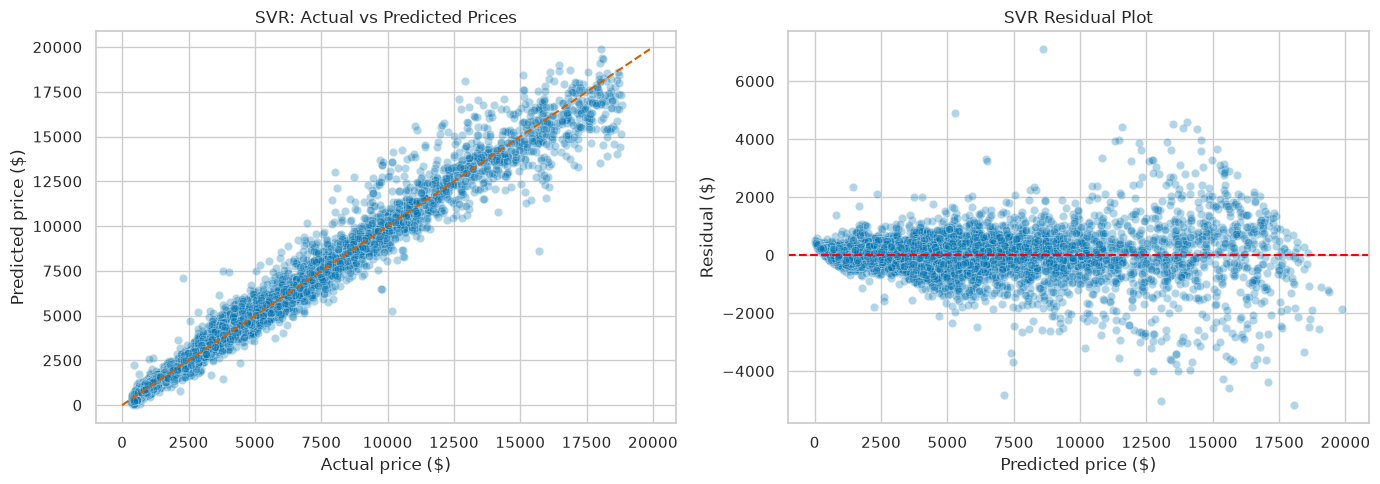

In [57]:
svr_residuals = y_test - svr_test_predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=y_test, y=svr_test_predictions, alpha=0.3, ax=axes[0])
plot_min = min(y_test.min(), svr_test_predictions.min())
plot_max = max(y_test.max(), svr_test_predictions.max())
axes[0].plot([plot_min, plot_max], [plot_min, plot_max], "r--")
axes[0].set(
    title="SVR: Actual vs Predicted Prices",
    xlabel="Actual price ($)",
    ylabel="Predicted price ($)",
)
sns.scatterplot(x=svr_test_predictions, y=svr_residuals, alpha=0.3, ax=axes[1])
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set(
    title="SVR Residual Plot",
    xlabel="Predicted price ($)",
    ylabel="Residual ($)",
)
plt.tight_layout()
plt.show()

## Comparison Through Model 9

The table contains every model currently implemented in this notebook and is ranked by test R². All nine models use the same untouched test set, so their metrics are directly comparable.

<ipython-input-1-8cb0f1fc076a>:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


                         Model  R2 Score      RMSE      MAE
0     Support Vector Regressor     0.979   579.208  335.188
1     Random Forest Regression     0.976   619.896  295.415
2  Gradient Boosting Regressor     0.964   751.938  384.848
3     Decision Tree Regression     0.963   766.689  361.614
4   Multiple Linear Regression     0.920  1125.164  735.216
5        Polynomial Regression     0.920  1125.164  735.216
6             Lasso Regression     0.918  1137.872  727.181
7             Ridge Regression     0.916  1150.890  727.534
8        ElasticNet Regression     0.912  1178.094  735.102

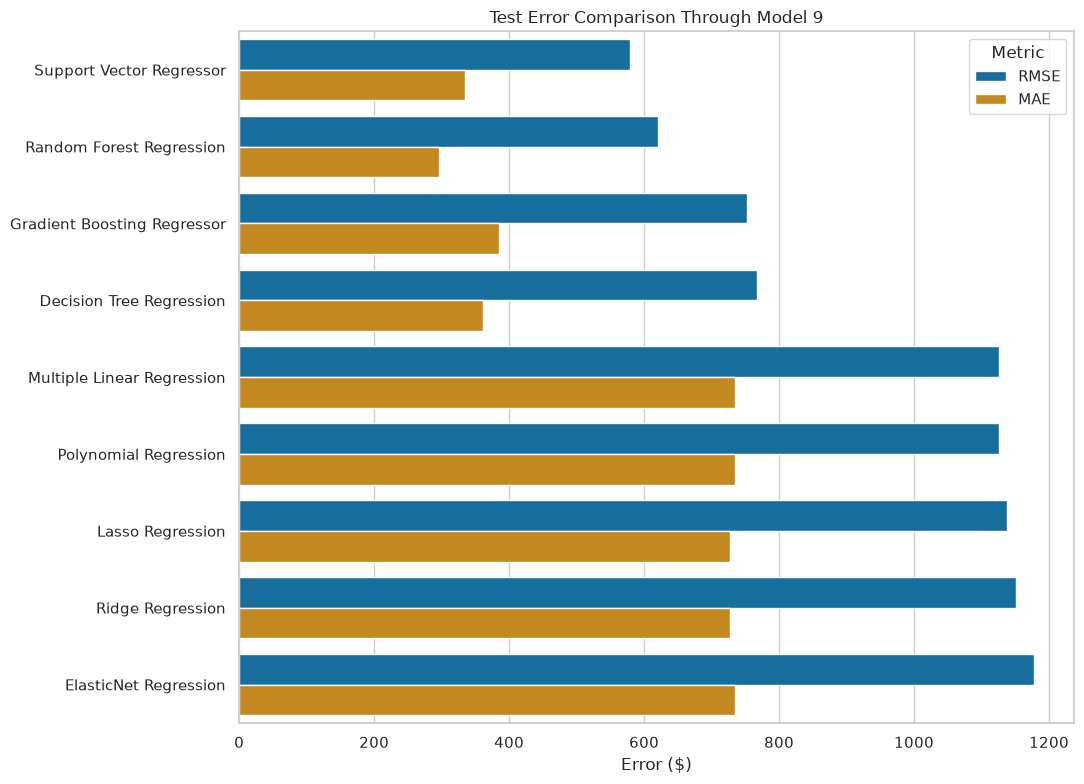

In [58]:
results_df = results_df.sort_values("R2 Score", ascending=False, ignore_index=True)
display(results_df.round(3))

comparison_long = results_df.melt(
    id_vars="Model",
    value_vars=["RMSE", "MAE"],
    var_name="Metric",
    value_name="Error ($)",
)
plt.figure(figsize=(11, 8))
sns.barplot(data=comparison_long, x="Error ($)", y="Model", hue="Metric")
plt.title("Test Error Comparison Through Model 9")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Model 9 takeaway

SVR offers a smooth nonlinear alternative, but kernel fitting is computationally expensive. The tuned result shows whether that cost produces a meaningful reduction in test error.

## Model 10: K-Nearest Neighbors Regressor

KNN Regression predicts a diamond's price from the prices of its most similar training diamonds. Similarity is measured using distance across the transformed feature space, so both the number of neighbors and feature scaling strongly affect the result.

### Step 1 — Prepare a reproducible tuning subset

Distance calculations become expensive when repeated during cross-validation. A fixed 8,000-row subset of the training data is therefore used to tune `k`; the test set remains completely untouched.

In [59]:
knn_tuning_size = min(8_000, len(X_train))
knn_tuning_indices = X_train.sample(
    n=knn_tuning_size, random_state=RANDOM_STATE
).index
X_knn_tuning = X_train.loc[knn_tuning_indices]
y_knn_tuning = y_train.loc[knn_tuning_indices]
print(f"KNN tuning rows: {len(X_knn_tuning):,}")

KNN tuning rows: 8,000


### Step 2 — Tune the number of neighbors (`k`)

Small `k` values produce flexible predictions but can overfit. Larger values create smoother predictions but may underfit. Three-fold cross-validation selects the `k` with the lowest RMSE. Distance weighting gives closer diamonds more influence than farther neighbors.

In [60]:
knn_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "regressor",
            KNeighborsRegressor(weights="distance", n_jobs=-1),
        ),
    ]
)

knn_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid={"regressor__n_neighbors": [3, 5, 7, 11, 15, 21]},
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=1,
)
knn_search.fit(X_knn_tuning, y_knn_tuning)
best_k = int(knn_search.best_params_["regressor__n_neighbors"])

knn_tuning_results = pd.DataFrame(
    {
        "k": knn_search.cv_results_["param_regressor__n_neighbors"],
        "CV RMSE": -knn_search.cv_results_["mean_test_score"],
    }
).sort_values("k", ignore_index=True)
print(f"Selected k: {best_k}")
display(knn_tuning_results.round(3))

Selected k: 7


    k   CV RMSE
0   3  1103.627
1   5  1078.099
2   7  1065.751
3  11  1069.539
4  15  1080.282
5  21  1096.541

<ipython-input-1-04abe8dbcbb1>:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


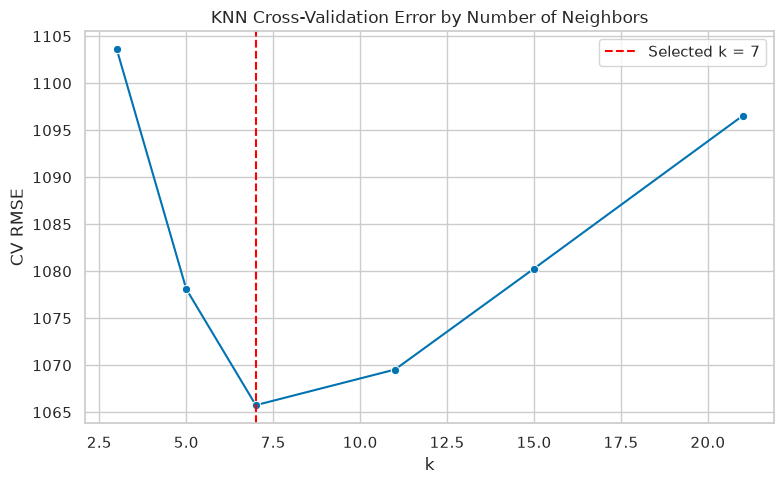

In [61]:
plt.figure(figsize=(8, 5))
sns.lineplot(
    data=knn_tuning_results, x="k", y="CV RMSE", marker="o"
)
plt.axvline(best_k, color="red", linestyle="--", label=f"Selected k = {best_k}")
plt.title("KNN Cross-Validation Error by Number of Neighbors")
plt.legend()
plt.tight_layout()
plt.show()

### Step 3 — Measure the impact of feature scaling

Without scaling, a feature with a large numeric range can dominate Euclidean distance even when it is not the most informative feature. The experiment below fits scaled and unscaled KNN models on identical rows and compares their validation errors. Categorical features are encoded identically in both cases.

In [62]:
X_knn_scale_train, X_knn_scale_validation, y_knn_scale_train, y_knn_scale_validation = (
    train_test_split(
        X_knn_tuning,
        y_knn_tuning,
        test_size=0.20,
        random_state=RANDOM_STATE,
    )
)

unscaled_numerical_pipeline = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median"))]
)
unscaled_preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", unscaled_numerical_pipeline, numerical_features),
        ("categorical", clone(categorical_pipeline), categorical_features),
    ]
)

scaled_knn_comparison = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        ("regressor", KNeighborsRegressor(n_neighbors=best_k, weights="distance")),
    ]
)
unscaled_knn_comparison = Pipeline(
    steps=[
        ("preprocessor", unscaled_preprocessor),
        ("regressor", KNeighborsRegressor(n_neighbors=best_k, weights="distance")),
    ]
)

scaling_rows = []
for scaling_label, comparison_model in [
    ("Standardized numerical features", scaled_knn_comparison),
    ("Unscaled numerical features", unscaled_knn_comparison),
]:
    comparison_model.fit(X_knn_scale_train, y_knn_scale_train)
    scaling_predictions = comparison_model.predict(X_knn_scale_validation)
    scaling_rows.append(
        {
            "Preprocessing": scaling_label,
            **regression_metrics(y_knn_scale_validation, scaling_predictions),
        }
    )

knn_scaling_results = pd.DataFrame(scaling_rows).sort_values(
    "RMSE", ignore_index=True
)
knn_scaling_results.round(3)

Out[0]: 
                     Preprocessing  R2 Score      RMSE      MAE
0  Standardized numerical features      0.93  1061.094  544.631
1      Unscaled numerical features      0.88  1388.322  735.315


### Step 4 — Train the selected scaled KNN model

The selected `k` is now used with standardized numerical features and the full training set.

In [63]:
knn_model = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "regressor",
            KNeighborsRegressor(
                n_neighbors=best_k, weights="distance", n_jobs=-1
            ),
        ),
    ]
)
knn_model.fit(X_train, y_train)
print("KNN training complete.")

KNN training complete.


### Step 5 — Evaluate KNN Regression

In [64]:
knn_train_predictions = knn_model.predict(X_train)
knn_test_predictions = knn_model.predict(X_test)

knn_train_metrics = regression_metrics(y_train, knn_train_predictions)
knn_test_metrics = regression_metrics(y_test, knn_test_predictions)

pd.DataFrame(
    [knn_train_metrics, knn_test_metrics],
    index=["Training set", "Test set"],
).round(3)

Out[0]: 
              R2 Score     RMSE      MAE
Training set     1.000    8.861    0.444
Test set         0.956  832.704  413.131


In [65]:
results_df = pd.concat(
    [
        results_df,
        pd.DataFrame(
            [{"Model": "K-Nearest Neighbors Regressor", **knn_test_metrics}]
        ),
    ],
    ignore_index=True,
).sort_values("R2 Score", ascending=False, ignore_index=True)

results_df.round(3)

Out[0]: 
                           Model  R2 Score      RMSE      MAE
0       Support Vector Regressor     0.979   579.208  335.188
1       Random Forest Regression     0.976   619.896  295.415
2    Gradient Boosting Regressor     0.964   751.938  384.848
3       Decision Tree Regression     0.963   766.689  361.614
4  K-Nearest Neighbors Regressor     0.956   832.704  413.131
5     Multiple Linear Regression     0.920  1125.164  735.216
6          Polynomial Regression     0.920  1125.164  735.216
7               Lasso Regression     0.918  1137.872  727.181
8               Ridge Regression     0.916  1150.890  727.534
9          ElasticNet Regression     0.912  1178.094  735.102


### Step 6 — Plot KNN predictions and residuals

<ipython-input-1-e0a91a78ed89>:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


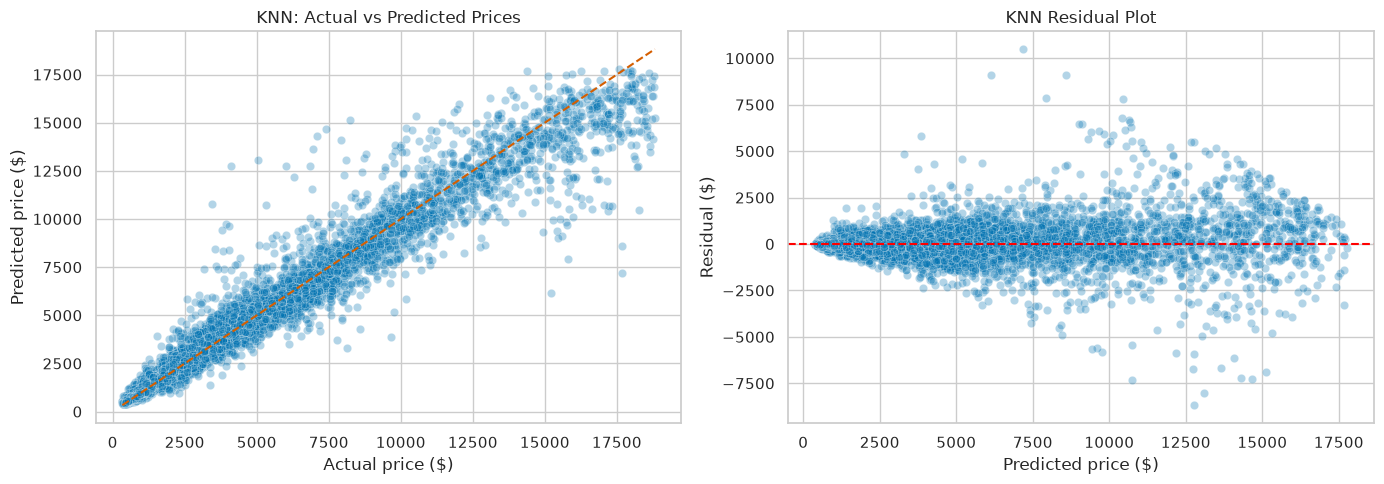

In [66]:
knn_residuals = y_test - knn_test_predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=y_test, y=knn_test_predictions, alpha=0.3, ax=axes[0])
plot_min = min(y_test.min(), knn_test_predictions.min())
plot_max = max(y_test.max(), knn_test_predictions.max())
axes[0].plot([plot_min, plot_max], [plot_min, plot_max], "r--")
axes[0].set(
    title="KNN: Actual vs Predicted Prices",
    xlabel="Actual price ($)",
    ylabel="Predicted price ($)",
)
sns.scatterplot(x=knn_test_predictions, y=knn_residuals, alpha=0.3, ax=axes[1])
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set(
    title="KNN Residual Plot",
    xlabel="Predicted price ($)",
    ylabel="Residual ($)",
)
plt.tight_layout()
plt.show()

## 6. Final comparison of all ten regression models

The table ranks the common test-set results by R². Model choice should also consider RMSE, MAE, overfitting, and interpretability rather than relying on one number.

In [67]:
final_results = results_df.sort_values(
    "R2 Score", ascending=False, ignore_index=True
)
display(final_results.round(3))

best_model = final_results.iloc[0]
print(f"Best model by test R²: {best_model['Model']}")
print(f"R²: {best_model['R2 Score']:.4f}")
print(f"RMSE: ${best_model['RMSE']:,.3f}")
print(f"MAE: ${best_model['MAE']:,.3f}")

Best model by test R²: Support Vector Regressor
R²: 0.9788
RMSE: $579.208
MAE: $335.188


                           Model  R2 Score      RMSE      MAE
0       Support Vector Regressor     0.979   579.208  335.188
1       Random Forest Regression     0.976   619.896  295.415
2    Gradient Boosting Regressor     0.964   751.938  384.848
3       Decision Tree Regression     0.963   766.689  361.614
4  K-Nearest Neighbors Regressor     0.956   832.704  413.131
5     Multiple Linear Regression     0.920  1125.164  735.216
6          Polynomial Regression     0.920  1125.164  735.216
7               Lasso Regression     0.918  1137.872  727.181
8               Ridge Regression     0.916  1150.890  727.534
9          ElasticNet Regression     0.912  1178.094  735.102

<ipython-input-1-8c91e82ddb09>:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


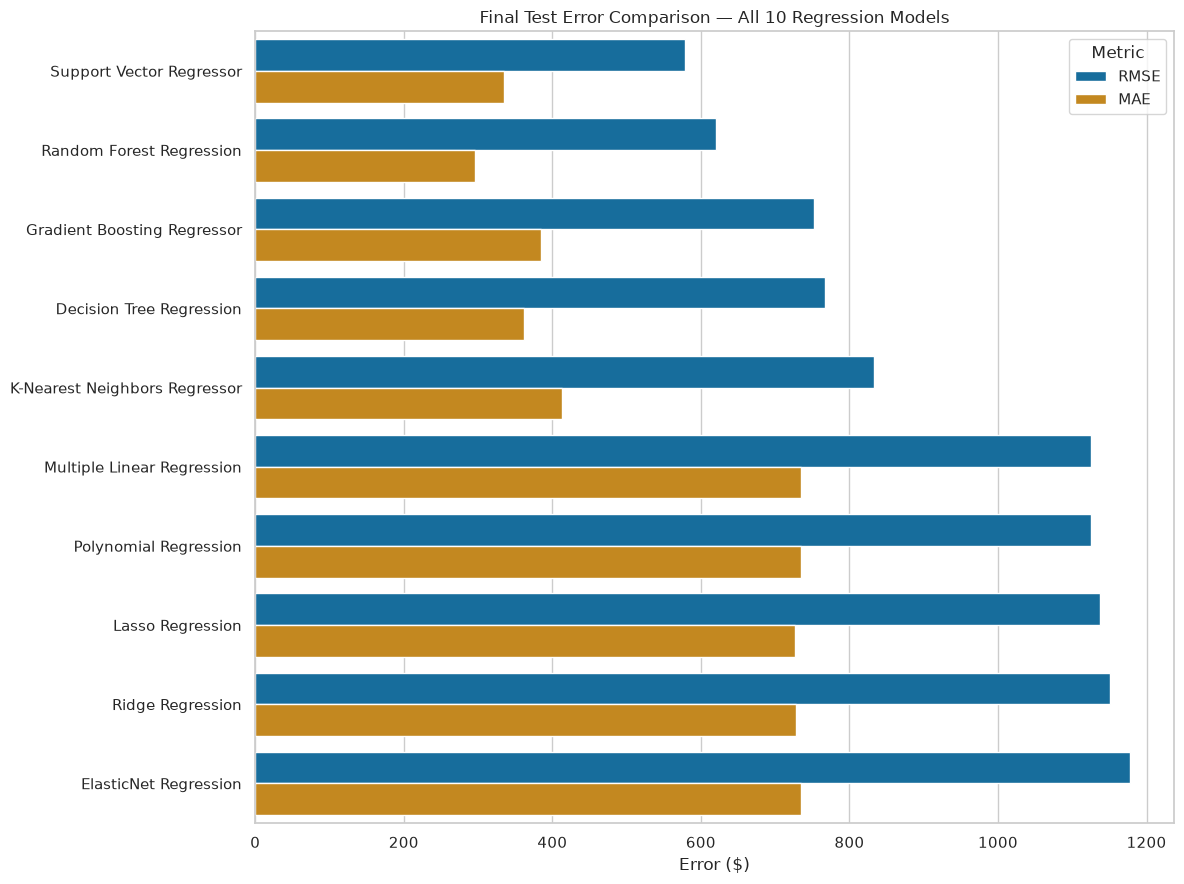

In [68]:
final_comparison_long = final_results.melt(
    id_vars="Model",
    value_vars=["RMSE", "MAE"],
    var_name="Metric",
    value_name="Error ($)",
)
plt.figure(figsize=(12, 9))
sns.barplot(
    data=final_comparison_long,
    x="Error ($)",
    y="Model",
    hue="Metric",
)
plt.title("Final Test Error Comparison — All 10 Regression Models")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 7. Five-fold validation of the two leading models

The rubric requires five-fold cross-validated R² for the two best test-set models. Cross-validation is run on the training split only; the held-out test set remains unchanged.

In [69]:
model_lookup = {
    "Multiple Linear Regression": linear_regression_model,
    "Ridge Regression": ridge_model,
    "Lasso Regression": lasso_model,
    "ElasticNet Regression": elastic_net_model,
    "Polynomial Regression": polynomial_model,
    "Decision Tree Regression": decision_tree_model,
    "Random Forest Regression": random_forest_model,
    "Gradient Boosting Regressor": gradient_boosting_model,
    "Support Vector Regressor": svr_model,
    "K-Nearest Neighbors Regressor": knn_model,
}

cross_validation_rows = []
for model_name in final_results.head(2)["Model"]:
    fold_scores = cross_val_score(
        model_lookup[model_name],
        X_train,
        y_train,
        scoring="r2",
        cv=5,
        n_jobs=1,
    )
    cross_validation_rows.append(
        {
            "Model": model_name,
            "Mean CV R2": fold_scores.mean(),
            "CV R2 standard deviation": fold_scores.std(),
            "Fold R2 scores": np.round(fold_scores, 4),
        }
    )

cross_validation_results = pd.DataFrame(cross_validation_rows)
cross_validation_results

Out[0]: 
                      Model  ...                           Fold R2 scores
0  Support Vector Regressor  ...   [0.977, 0.978, 0.9795, 0.9762, 0.9766]
1  Random Forest Regression  ...  [0.9701, 0.9718, 0.9771, 0.969, 0.9719]

[2 rows x 4 columns]


**Interpretation.** The mean shows performance across five different validation folds, while the standard deviation shows stability. A model with a slightly lower mean but much lower variation may be the safer final choice.

### Model 10 takeaway

KNN makes local predictions without fitting a global equation. The scaling comparison demonstrates why distance-based methods require comparable feature ranges.